# Your first simulation

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

The single experiment is Larvaworld's default simulation mode and the foundation of every other
one : a batch run is many single experiments, a genetic algorithm is many single experiments scored
against data, an evaluation is a single experiment compared with a recording.

This notebook launches one. We use `chemorbit`, a preconfigured chemotaxis experiment in which
larvae are placed in a dish with a single odor source and, if their model can smell, orbit it.
Nothing has to be downloaded and the run takes a few seconds.

**What you will be able to do afterwards**

- List the experiments that ship with Larvaworld and load one by its ID.
- Read an experiment configuration : what is in it and what each part controls.
- Launch a run headless or with a window, and set its duration and population size.
- Find the datasets a run produced and the analysis registered for that experiment.

**Prerequisites** : Larvaworld installed. No data required.

**Cost** : the demo run below is 0.1 simulated minutes with 5 larvae - a few seconds.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_SIM_DEMO` | `True` | the short headless simulation - cheap, left on |
| `RUN_GUI_DEMO` | `False` | the same run with a pygame window, which needs a display |
| `RUN_ANALYZE_DEMO` | `False` | the post-run analysis, which produces many figures |

## Setup

Importing `larvaworld` initializes its configuration registry : part of it is read from disc, the
rest is built on the fly. `VERBOSE = 1` makes that process report what it is doing, which is worth
watching the first time.

In [1]:
%matplotlib inline

%load_ext param.ipython

import larvaworld as lw
from larvaworld.lib import reg
from larvaworld.lib.reg.generators import ExpConf
from larvaworld.lib.reg.larvagroup import LarvaGroup
from larvaworld.lib.sim.single_run import ExpRun

lw.VERBOSE = 1

# Tutorial safety switches
RUN_SIM_DEMO = True  # short headless simulation (cheap)
RUN_GUI_DEMO = False  # opens a pygame window
RUN_ANALYZE_DEMO = False  # full analysis, produces many figures

EXPERIMENT_ID = "chemorbit"
DEMO_N = 5  # larvae per group
DEMO_DURATION_MIN = 0.1  # simulated minutes
DEMO_SCREEN_KWS = {}  # headless

Welcome to the param IPython extension! (https://param.holoviz.org/)
Available magics: %params


Initializing larvaworld registry


Registry configured!


## Section 1 : What an experiment is made of

An **experiment** in Larvaworld is a configuration object, not a script. Everything that defines
the run is data : how long it lasts, what the arena looks like, which animals are in it, and what
should be measured. `ExpConf` is the class holding all of that.

The `%params` magic prints a class's parameters with their types, defaults and documentation. Look
for four things in the output below - they are the four parts every experiment has :

- **simulation options** - `duration`, `dt`, `Box2D` and friends,
- **`env_params`** - the arena, its geometry, food and sensory landscapes,
- **`larva_groups`** - who is in the dish,
- **`collections` / `enrichment`** - what gets recorded and computed afterwards.

In [2]:
# The experiment configuration class
%params ExpConf

### Larva groups

`larva_groups` is the part that most often needs changing. A group is *N* copies of one model,
placed according to a spatial distribution, drawn in one color and labelled with one ID. An
experiment can hold several groups, which is how a virtual control-vs-treatment comparison is set
up : same arena, different models or different placements.

In [3]:
# The larva-group class
%params LarvaGroup

## Section 2 : Picking a preconfigured experiment

Larvaworld ships with a catalog of experiments that reproduce standard behavioral assays -
free exploration in a dish, chemotaxis towards an odor source, foraging on patches, and so on.
Each is stored in the registry under a unique ID.

In [4]:
# Every stored experiment ID
print(reg.conf.Exp.confIDs)

['4corners', 'MB_patch_grid', 'PItest_off', 'PItest_off_OSN', 'PItest_off_RL', 'PItest_on', 'PItrain', 'PItrain_mini', 'RvsS', 'RvsS_off', 'RvsS_on', 'RvsS_on_1h_prestarved', 'RvsS_on_2h_prestarved', 'RvsS_on_3h_prestarved', 'RvsS_on_4h_prestarved', 'RvsS_on_q15', 'RvsS_on_q25', 'RvsS_on_q50', 'RvsS_on_q75', 'anemotaxis', 'anemotaxis_bordered', 'capture_the_flag', 'catch_me', 'chemorbit', 'chemorbit_OSN', 'chemorbit_x2', 'chemorbit_x4', 'chemotaxis', 'chemotaxis_RL', 'chemotaxis_diffusion', 'dish', 'dispersion', 'dispersion_x2', 'double_patch', 'focus', 'food_at_bottom', 'food_grid', 'growth', 'keep_the_flag', 'maze', 'multi_tactile_detection', 'noMB_patch_grid', 'patch_grid', 'patchy_food', 'prey_detection', 'puff_anemotaxis_bordered', 'random_food', 'realistic_imitation', 'reorientation', 'single_odor_patch', 'single_odor_patch_x4', 'single_puff', 'tactile_detection', 'tactile_detection_x4', 'test001', 'tethered', 'thermotaxis', 'uniform_food']


Loading one by ID returns its configuration as a nested dictionary. `chemorbit` places a single
odor source in a dish and one group of navigating larvae around it.

In [5]:
conf = reg.conf.Exp.getID(EXPERIMENT_ID)

print("Top-level keys :", conf.keylist)
print()
print("Larva groups :")
print(conf.larva_groups)

Top-level keys : ['Box2D', 'Nsteps', 'collections', 'constant_framerate', 'dt', 'duration', 'enrichment', 'env_params', 'experiment', 'fr', 'larva_collisions', 'larva_groups', 'parameter_dict', 'trials']

Larva groups :
{'navigator': {'color': 'black', 'distribution': {'N': 3, 'loc': (0.0, 0.0), 'mode': 'uniform', 'orientation_range': (0.0, 360.0), 'scale': (0.0, 0.0), 'shape': 'circle'}, 'group_id': 'navigator', 'imitation': False, 'life_history': {'age': 0.0, 'epochs': ItemList (0 objects), 'reach_pupation': False}, 'model': 'navigator', 'odor': {'id': None, 'intensity': None, 'spread': None}, 'sample': None}}


## Section 3 : Running it

`ExpRun` is the launcher. It accepts the experiment ID plus any runtime override you want -
duration, population size, display settings - and resolves the rest from the stored configuration.

In [6]:
# The launcher and its runtime arguments
%params ExpRun

Creating the object builds the run but does not start it; `simulate()` does. Note that the
population size we passed has already replaced the one stored in the configuration.

In [7]:
r = ExpRun(
    experiment=EXPERIMENT_ID,
    N=DEMO_N,
    duration=DEMO_DURATION_MIN,
    screen_kws=DEMO_SCREEN_KWS,
)

print(r.p.larva_groups)

{'navigator': {'color': 'black', 'distribution': {'N': 5, 'loc': (0.0, 0.0), 'mode': 'uniform', 'orientation_range': (0.0, 360.0), 'scale': (0.0, 0.0), 'shape': 'circle'}, 'group_id': 'navigator', 'imitation': False, 'life_history': {'age': 0.0, 'epochs': ItemList (0 objects), 'reach_pupation': False}, 'model': 'navigator', 'odor': {'id': None, 'intensity': None, 'spread': None}, 'sample': None}}


In [8]:
if RUN_SIM_DEMO:
    r.simulate()
    print(f"Produced {len(r.datasets)} dataset(s) :")
    for d in r.datasets:
        print(f"  {d.id} : {d.config.N} larvae, stored at {d.dir}")

--- Simulation chemorbit_26 initialized!--- 
--- Simulation chemorbit_26 : Generating agent groups!--- 



Run time: 0:00:00.525684
Simulation finished
--- Simulation chemorbit_26 completed in 1 seconds!--- 
--- Enriching dataset navigator ---
Vector orientations are already computed. If you want to recompute them, set recompute to True
Angular analysis complete.
Spatial analysis complete.
Bearing and distance to source computed
--- Dataset navigator enriched ---
--------------------------------


***** Dataset navigator stored.-----
Simulation chemorbit_26 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_26
Produced 1 dataset(s) :
  navigator : 5 larvae, stored at C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_26/data/navigator


### The short form

`ExpRun.from_ID` builds *and* runs in one call. It is convenient when you only want the result and
do not need to inspect the configuration first - which is why it is shown here rather than used
above.

```python
r_quick = ExpRun.from_ID(EXPERIMENT_ID, N=5)
```

### With a window

The same run, rendered. `vis_mode="video"` opens a pygame window; it needs a display, so it stays
off in this notebook. The keyboard controls available during a run are listed in the
[keyboard controls](../../visualization/keyboard_controls.md) reference.

In [9]:
if RUN_GUI_DEMO:
    r_gui = ExpRun(
        experiment=EXPERIMENT_ID,
        N=DEMO_N,
        duration=DEMO_DURATION_MIN,
        screen_kws={"vis_mode": "video"},
    )
    r_gui.simulate()

## Section 4 : What comes out

Every experiment has an analysis attached to it - a list of plot groups appropriate to what it
measures. A chemotaxis experiment plots orientation to the source; an exploration experiment plots
dispersal. You can see which ones apply before running them.

In [10]:
print(r.graphgroups)

{'traj': [{'key': 'trajectories', 'plotID': 'trajectories', 'args': {'mode': 'default', 'unit': 'mm'}}, {'key': 'aligned2origin', 'plotID': 'trajectories', 'args': {'mode': 'origin', 'unit': 'mm', 'single_color': True, 'name': 'aligned2origin'}}], 'general': [{'key': 'epochs', 'plotID': 'epochs', 'args': {'stridechain_duration': True}}], 'chemo': [{'key': 'chemosensation', 'plotID': 'timeplots', 'args': {'ks': ['c_odor1', 'dc_odor1', 'A_olf', 'A_T', 'I_T'], 'individuals': False, 'name': 'chemosensation'}}, {'key': 'trajectories', 'plotID': 'trajectories', 'args': {}}], 'locomotion_relative_to_source_Object': [{'key': 'bearing_to_Object', 'plotID': 'timeplot', 'args': {'pars': ['bearing_to_Object'], 'name': 'bearing_to_Object'}}, {'key': 'dst_to_Object', 'plotID': 'timeplot', 'args': {'pars': ['dst_to_Object'], 'name': 'dst_to_Object'}}, {'key': 'scaled_dst_to_Object', 'plotID': 'timeplot', 'args': {'pars': ['scaled_dst_to_Object'], 'name': 'scaled_dst_to_Object'}}]}


### A first figure

Running the whole analysis is overkill for a 0.1-minute run, but a single plot is not. Plot
routines are called by name through `reg.graphs.run`, and they take the datasets to draw - so the
same call works on simulated and on recorded animals.

The paths below are what five `navigator` larvae did around the odor source at the centre of the
dish.

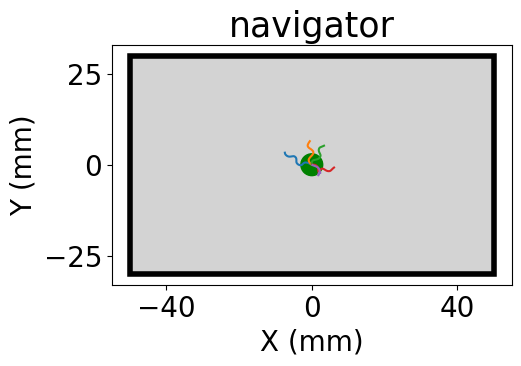

In [11]:
if RUN_SIM_DEMO and r.datasets:
    display(
        reg.graphs.run("trajectories", datasets=r.datasets, show=False, save_to=None)
    )

`analyze()` runs them all and writes the figures next to the datasets. It is off by default here
because it produces a lot of output for a 0.1-minute run.

In [12]:
if RUN_ANALYZE_DEMO:
    r.analyze()

## Where to go next

- [The Python API](python_api_basics.ipynb) - change the experiment instead of just running it.
- [The configuration registry](../4_models_and_environments/configuration_registry.ipynb) - where
  the stored experiments come from and how to add your own.
- [Model evaluation](../5_optimization_and_evaluation/model_evaluation.ipynb) - compare what you
  simulated against real animals.
- Reference : [Single Experiments](../../working_with_larvaworld/single_experiments.md) and
  [Experiment types](../../concepts/experiment_types.md).